In [1]:
import numpy as np # used for array operations
import brian2 as b2 # used for neural simulation
from brian2 import NeuronGroup, Synapses, PoissonGroup, SpikeMonitor, run, ms, Hz, PoissonInput
from scipy.stats import poisson, binom # used for stats (mean, s.d.)
import matplotlib.pyplot as plt # used for plotting
import json # to serialize
b2.prefs.codegen.target = "numpy" # set Brian2 to use numpy backend

In [2]:
# **Step 1: Generate Independent Poisson Processes**
def independent_poisson_processes(num_neurons, rate, time, num_samples):
    ind_processes = []
    spike_trains = []
    
    for _ in range(num_samples):
        sample_processes = []
        sample_spike_train = []
        for i in range(num_neurons):
            P = PoissonGroup(n, rate * b2.Hz)
            spike_monitor = SpikeMonitor(P)
            run(time * ms)
            spike_times = spike_monitor.spike_trains()[0]
            ind_process = np.zeros(int(time))  # Initialize with zeros
            for t in spike_times:
                if t < time * ms:
                    ind_process[int(t / ms)] = 1  # Convert t to unitless
            sample_processes.append(ind_process)
            sample_spike_train.append(spike_times)
    
        ind_processes.extend(sample_processes)  # Use extend instead of append
        spike_trains.extend(sample_spike_train)  # Use extend instead of append
    
    return ind_processes, spike_trains

In [3]:
# **Step 2: Generate Correlated Poisson Processes**
def correlated_poisson_processes(num_neurons, rate, time, num_common, num_samples):
    cor_processes = []
    for _ in range(num_samples):
        sample_processes = []
        independent_procs = []
        for i in range(num_neurons + num_common):
            # Using Brian2's PoissonGroup to generate a Poisson process
            P = b2.PoissonGroup(1, rate*b2.Hz)
            spike_monitor = b2.SpikeMonitor(P)
            b2.run(time * b2.ms)
            spike_times = spike_monitor.spike_trains()[0]
            # Convert spike times to a binary array
            cor_process = [0] * int(time)
            for t in spike_times:
                if t < time * b2.ms:  # Ensure units match
                    cor_process[int(t / b2.ms)] = 1  # Convert t to unitless
            independent_procs.append(cor_process)
        
        for i in range(num_neurons):
            if i < num_common:
                cor_process = [sum(x) for x in zip(*independent_procs[:i+1])]
            else:
                cor_process = independent_procs[i+num_common]
            sample_processes.append(cor_process)
        cor_processes.append(sample_processes)
    return cor_processes

In [4]:
def calculate_mean_and_variance(counting_process_nd_result):
    num_samples, num_neurons_to_plot, time = counting_process_nd_result.shape
    mean = np.mean(counting_process_nd_result, axis=0)
    variance = np.var(counting_process_nd_result, axis=0)
    return mean, variance

In [5]:
def counting_process_nd(independent_processes, num_samples, time, num_neurons_to_plot):
    counting_process_nd = np.zeros((num_samples, num_neurons_to_plot, time))
    for i in range(num_samples):
        counts = np.zeros(num_neurons_to_plot)
        for j in range(time):
            for k in range(num_neurons_to_plot):
                if independent_processes[i + k * num_samples][j] == 1:
                    counts[k] += 1
            counting_process_nd[i, :, j] = counts
    return counting_process_nd

In [6]:
def plot_count_neuron1_vs_time(counting_process_nd, num_samples):
    plt.figure(figsize=(10,6))
    for i in range(num_samples):
        plt.plot(counting_process_nd[i][0], label=f'Sample {i}')
    #mean_neuron1 = np.mean([counting_process_nd[i][0] for i in range(num_samples)], axis=0)
    #plt.plot(mean_neuron1, label='Mean', color='black', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Count of Neuron 1')
    plt.title('Count of Neuron 1 Over Time')
    plt.ylim(0, None)  # Set y-axis lower limit to 0
    plt.show()

In [7]:
def plot_centered_staircase(counting_process_nd, num_samples, expected_mean):
    plt.figure(figsize=(10,6))
    for i in range(num_samples):
        plt.plot(counting_process_nd[i][0] - expected_mean, label=f'Sample {i}')
    mean_centered = np.mean([counting_process_nd[i][0] - expected_mean for i in range(num_samples)], axis=0)
    plt.plot(mean_centered, label='Mean', color='black', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Centered Count of Neuron 1')
    plt.title('Centered Count of Neuron 1 Over Time')
    plt.show()

In [8]:
def plot_standardized_staircase(counting_process_nd, num_samples, expected_mean):
    std_dev = np.std([counting_process_nd[i][0] for i in range(num_samples)], axis=0)
    plt.figure(figsize=(10,6))
    for i in range(num_samples):
        plt.plot((counting_process_nd[i][0] - expected_mean) / std_dev, label=f'Sample {i}')
    mean_standardized = np.mean([(counting_process_nd[i][0] - expected_mean) / std_dev for i in range(num_samples)], axis=0)
    plt.plot(mean_standardized, label='Mean', color='black', linewidth=2)
    plt.xlabel('Time')
    plt.ylabel('Standardized Count of Neuron 1')
    plt.title('Standardized Count of Neuron 1 Over Time')
    plt.show()

In [9]:
def plot_centered_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Iterate through the number of samples
    for i in range(num_samples):
        # Ensure that counting_process_nd_result[i] is structured correctly
        neuron1_data = counting_process_nd_result[i][0] - theoretical_means[0]
        neuron2_data = counting_process_nd_result[i][1] - theoretical_means[1]
        
        # Plot the data, by subtracting by the theoretical_means, i should be centering the data but it is not doing that ....
        ax.plot(range(len(neuron1_data)), neuron2_data, neuron1_data)

    # Calculate mean centered data for both neurons 
#    mean_centered_neuron1 = np.mean([(counting_process_nd_result[i][0] - theoretical_means[0]) / theoretical_std_dev[0] for i in range(num_samples)], axis=0)
#    mean_centered_neuron2 = np.mean([(counting_process_nd_result[i][1] - theoretical_means[1]) / theoretical_std_dev[1] for i in range(num_samples)], axis=0)

    # Plot mean centered data
#    ax.plot(range(len(mean_centered_neuron1)), mean_centered_neuron2, mean_centered_neuron1, color='black', linewidth=2)

    ax.set_xlabel('Time')
    ax.set_ylabel('Centered Count of Neuron 2')
    ax.set_zlabel('Centered Count of Neuron 1', rotation=90)
    ax.set_title('Centered Count of Neuron 1 vs Centered Count of Neuron 2 vs Time')

    ax.set_xlim(0, max(len(counting_process_nd_result[i][0]) for i in range(num_samples)))
#    max_val = max(max((counting_process_nd_result[i][1] - theoretical_means[1]) / theoretical_std_dev[1]) for i in range(num_samples))
#    ax.set_ylim(-max_val, max_val)
#    max_val = max(max((counting_process_nd_result[i][0] - theoretical_means[0]) / theoretical_std_dev[0]) for i in range(num_samples))
#    ax.set_zlim(-max_val, max_val)

    plt.show()


In [10]:
def plot_standardized_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev, t0):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Iterate through the number of samples
    for i in range(num_samples):
        # Ensure that counting_process_nd_result[i] is structured correctly
        neuron1_data = (counting_process_nd_result[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
        neuron2_data = (counting_process_nd_result[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
        
        # Plot the data, len(neuron1_data) should be = to len(neuron2_data) so either can be used
        ax.plot(range(t0,len(neuron1_data)), neuron2_data[t0:], neuron1_data[t0:])

    # Calculate mean standardized data for both neurons
#    mean_standardized_neuron1 = np.mean([counting_process_nd_result[i][0] / theoretical_std_dev[0] for i in range(num_samples)], axis=0)
#    mean_standardized_neuron2 = np.mean([counting_process_nd_result[i][1] / theoretical_std_dev[1] for i in range(num_samples)], axis=0)

    # Plot mean standardized data
#     ax.plot(range(len(mean_standardized_neuron1)), mean_standardized_neuron2, mean_standardized_neuron1, color='black', linewidth=2)

    ax.set_xlabel('Time')
    ax.set_ylabel('Standardized Count of Neuron 2')
    ax.set_zlabel('Standardized Count of Neuron 1', rotation=90)
    ax.set_title('Standardized Count of Neuron 1 vs Standardized Count of Neuron 2 vs Time')

#    ax.set_xlim(100, max(len(counting_process_nd_result[i][0]) for i in range(num_samples)))
#    ax.set_ylim(min(min(counting_process_nd_result[i][1] / theoretical_std_dev[1]) for i in range(num_samples)),
#                max(max(counting_process_nd_result[i][1] / theoretical_std_dev[1]) for i in range(num_samples)))
#    ax.set_zlim(min(min(counting_process_nd_result[i][0] / theoretical_std_dev[0]) for i in range(num_samples)),
#                max(max(counting_process_nd_result[i][0] / theoretical_std_dev[0]) for i in range(num_samples)))

    plt.show()


In [11]:
def plot_count_neuron1_vs_neuron2_vs_time(counting_process_nd, num_samples):
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_subplot(111, projection='3d')
    for i in range(num_samples):
        ax.plot(counting_process_nd[i][0], counting_process_nd[i][1], range(len(counting_process_nd[i][0])))
    mean_neuron1 = np.mean([counting_process_nd[i][0] for i in range(num_samples)], axis=0)
    mean_neuron2 = np.mean([counting_process_nd[i][1] for i in range(num_samples)], axis=0)
    ax.plot(mean_neuron1, mean_neuron2, range(len(mean_neuron1)), color='black', linewidth=2)
    ax.set_xlabel('Count of Neuron 1')
    ax.set_ylabel('Count of Neuron 2')
    ax.set_zlabel('Time', rotation=90)
    ax.set_title('Count of Neuron 1 vs Count of Neuron 2 vs Time')
    ax.set_xlim(0, max([max(counting_process_nd[i][0]) for i in range(num_samples)]))
    ax.set_ylim(0, max([max(counting_process_nd[i][1]) for i in range(num_samples)]))
    ax.set_zlim(0, max([len(counting_process_nd[i][0]) for i in range(num_samples)]))
    plt.show()

In [12]:
def calculate_theoretical_mean(rate, time):
    theoretical_mean = np.zeros((2, time))
    for i in range(time):
        theoretical_mean[0, i] = (rate * (i)) / 1000 
        theoretical_mean[1, i] = (rate * (i)) / 1000 
    return theoretical_mean

In [13]:
def calculate_theoretical_std_dev(theoretical_means):
    return np.sqrt(theoretical_means)

In [14]:
def empirical_mean(counting_process_nd_result):
    """
    Calculate the empirical mean of a list of numerical samples.

    Parameters:
    samples (list): A list of numerical values (int or float) from which to calculate the empirical mean.

    Returns:
    float: The empirical mean of the samples.
    """
    total = 0

    for sample in counting_process_nd_result:
        total += sample

    # np.mean(total) test this with the list of samples
    mean = total / num_samples
    return mean

In [15]:
def simulate_lif_network(num_neurons, num_samples, rate, time, I):
    '''
    ***simulate_lif_network(num_neurons, num_samples, rate, time, I)***
    inputs
    num_neurons - The number of neurons to simulate
    num_samples - The number of samples for the simulation
    rate - The firing rate of the Poisson inputs
    time - The duration of the simulation
    I - The input current to the LIF model

    Simulates a small LIF neural network with random connectivity, driven by Poisson inputs.

    outputs
    spike_trains - A dictionary of spike trains, where each key is a neuron index and each value is a list of spike times
    '''
    # Convert time to milliseconds to Brian2 units
    simulation_time = time * b2.ms

    # Create LIF neurons and monitor their spikes
    neurons = b2.NeuronGroup(num_neurons, '''
    dv/dt = (-v + I) / (10*ms) : 1
    I : 1  # Define I as a variable
    ''', threshold='v > 1', reset='v = 0')
    spike_monitor = b2.SpikeMonitor(neurons)

    # Set the input current
    neurons.I = I

    # Create Poisson inputs
    inputs = b2.PoissonInput(target=neurons, target_var='v', N=num_neurons, rate=rate * b2.Hz, weight=1)

    # Create synapses between neurons with random connectivity
    synapses = b2.Synapses(neurons, neurons, model='w:1', on_pre='v += w * 0.1') # 0.1 use with care, may need to go to 2 and 3 for small networks (like this one)
    # increased 0.1 to 2 and i got way too many spikes
    synapses.connect(p=0.5)  # Random connectivity, better to use i != j so you don't have same connections
    # check the connection matrix first, subtract 1/2 and multiply by 2, if we want more negative, make the probability lower (1/4)
    # for synaptic spikes, we will get inhibitory and exhibitory currents

    # Initialize weights
    synapses.w = 'rand()'  # Initialize weights randomly

    # Create a network
    net = b2.Network(neurons, inputs, spike_monitor, synapses)

    # Run the network
    net.run(simulation_time)

    # Return the spike times
    return spike_monitor.spike_trains()


In [16]:
# Assessment code
def assess_spike_trains(spike_trains, time, num_neurons):
    num_spikes = 0
    for neuron in spike_trains:
        num_spikes += len(spike_trains[neuron])
    sum_spikes = num_spikes
    print("Sum of spikes per second per neuron: ", sum_spikes / (time / 1000) / num_neurons)

In [17]:
def dotted_point_poisson_plot(counting_process_nd, num_samples, independent_processes):
    fig, ax1 = plt.subplots(figsize=(10,6))
    colors = plt.cm.rainbow(np.linspace(0, 1, num_samples))
    
    for i in range(num_samples):
        spike_times = np.where(independent_processes[i + 0 * num_samples] == 1)[0]
        ax1.scatter(spike_times, np.zeros(len(spike_times)), color=colors[i], marker='|', s=100)
        ax1.plot(counting_process_nd[i][0], color=colors[i], label=f'Sample {i}')
    
    mean_neuron1 = np.mean([counting_process_nd[i][0] for i in range(num_samples)], axis=0)
    ax1.plot(mean_neuron1, label='Mean', color='black', linewidth=2)
    
    ax1.plot([empirical_mean]*len(counting_process_nd[0][0]), label='Empirical Mean', color='blue', linewidth=2)
    
    ax2 = ax1.twinx()
    ax2.plot(counting_process_nd[0][0], color='red', label='Counting Process')
    ax2.set_ylabel('Counting Process')
    
    theoretical_mean = np.zeros(len(counting_process_nd[0][0]))
    theoretical_mean[:] = 5  # Replace with your theoretical mean value
    ax1.plot(theoretical_mean, label='Theoretical Mean', color='green', linewidth=2)
    
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Count of Neuron 1')
    ax1.set_title('Count of Neuron 1 Over Time')
    ax1.set_ylim(0, None)  # Set y-axis lower limit to 0
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()

In [18]:
def raster_plot(independent_processes, num_samples):
    fig = plt.figure(figsize=(12,8))
    for i in range(num_samples):
        spike_times = np.where(independent_processes[i + 0 * num_samples] == 1)[0]
        plt.scatter([i]*len(spike_times), spike_times, s=10, color='blue', alpha=0.6)
    plt.xlabel('Neuron Index')
    plt.ylabel('Time')
    plt.title('Raster Plot')
    plt.show()

In [19]:
# Parameters
num_neurons = 10 # set this to 10 later
rate = 10 # brian 2 units
t0 = 200
time = 1000
num_common = 2
num_samples = 10 #later set this to 10, then 100. 1 lets there be one replicate
I = 0.5
area = (10, 10)  # area dimensions (width, height)
# note under 100 spikes per neuron should be good, right now I have 3000...

In [20]:
SNN = simulate_lif_network(num_neurons, num_samples, rate, time, I)
print(SNN)
# why are there not lots of 1s in the independent poisson processes
# make an assessment code that takes the dictionary, return SN and num spikes,
# and print sum_spikes divided by time and network size. Needs to be not 0 not infninty, needs to be close to 100

INFO       No numerical integration method specified for group 'neurongroup', using method 'exact' (took 0.03s). [brian2.stateupdaters.base.method_choice]
WARNING    'I' is an internal variable of group 'neurongroup', but also exists in the run namespace with the value 0.5. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


{0: array([0.0092, 0.0172, 0.0374, 0.0716, 0.0772, 0.0798, 0.0812, 0.0966,
       0.1082, 0.11  , 0.1254, 0.1367, 0.1792, 0.1846, 0.1856, 0.2184,
       0.2226, 0.2229, 0.2243, 0.225 , 0.2328, 0.2334, 0.234 , 0.2349,
       0.2377, 0.2381, 0.258 , 0.2615, 0.2638, 0.2859, 0.2963, 0.3009,
       0.3078, 0.3081, 0.3123, 0.3185, 0.3329, 0.3358, 0.3625, 0.3767,
       0.4083, 0.4202, 0.4224, 0.463 , 0.4692, 0.4766, 0.492 , 0.4967,
       0.5014, 0.5119, 0.5139, 0.534 , 0.5475, 0.5581, 0.5626, 0.575 ,
       0.593 , 0.6386, 0.6389, 0.666 , 0.7036, 0.7258, 0.7365, 0.752 ,
       0.7645, 0.7762, 0.7769, 0.7778, 0.7808, 0.7832, 0.7967, 0.7981,
       0.8041, 0.813 , 0.8394, 0.8617, 0.8983, 0.8994, 0.902 , 0.918 ,
       0.9261, 0.9342, 0.9353, 0.9477, 0.9533, 0.9577, 0.9633, 0.9777,
       0.9789, 0.9796, 0.9949]) * second, 1: array([0.0072, 0.0078, 0.0081, 0.0196, 0.0295, 0.0452, 0.0489, 0.065 ,
       0.0724, 0.0791, 0.0822, 0.0837, 0.0882, 0.0906, 0.1124, 0.1161,
       0.1391, 0.1591, 0.163

In [21]:
assess_spike_trains(SNN, time, num_neurons)

Sum of spikes per second per neuron:  100.6


In [22]:
independent_processes, spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
#print(independent_processes)
# print(spike_train)
# getting list of a list, don't need to return a list of the variable

In [23]:
print(spike_train)

[array([ 14.7, 184.1, 395.7, 396.1, 583.3, 751.6, 822.3]) * msecond, array([0.1195, 0.148 , 0.227 , 0.5771, 0.6089, 0.8171, 0.8707, 0.8818,
       0.8897]) * second, array([ 22. , 103.9, 164.7, 275.8, 307.7, 470.2, 537.1, 558.9, 602.4,
       911.4]) * msecond, array([0.2573, 0.3543, 0.4274, 0.4896, 0.7879, 0.9475, 0.9523]) * second, array([ 87.4, 128. , 130.3, 283. , 289.9, 392. , 399.5, 897.9, 948.4]) * msecond, array([0.189 , 0.5383, 0.6322]) * second, array([  0. ,  96.2,  98.9, 152.4, 188.6, 244.6, 265.3, 661.6, 796.9,
       954.2]) * msecond, array([0.1253, 0.1445, 0.2453, 0.2883, 0.5521, 0.5608, 0.6237, 0.651 ,
       0.7767, 0.8678, 0.9336]) * second, array([0.048 , 0.1546, 0.3349, 0.4209, 0.4636, 0.5643, 0.6164, 0.7434]) * second, array([0.0605, 0.2422, 0.2789, 0.5519, 0.5563, 0.6609, 0.6925, 0.7334]) * second, array([0.1928, 0.2038, 0.232 , 0.4341, 0.577 , 0.6869, 0.6975]) * second, array([0.1814, 0.1815, 0.192 , 0.3285, 0.6441, 0.7524, 0.8601, 0.9968]) * second, array([ 41.

In [24]:
counting_process_nd_result = counting_process_nd(independent_processes, num_samples, time, 2)

In [25]:
print(counting_process_nd_result)

[[[ 0.  0.  0. ...  7.  7.  7.]
  [ 0.  0.  0. ...  7.  7.  7.]]

 [[ 0.  0.  0. ...  9.  9.  9.]
  [ 0.  0.  0. ...  7.  7.  7.]]

 [[ 0.  0.  0. ... 10. 10. 10.]
  [ 0.  0.  0. ... 13. 13. 13.]]

 ...

 [[ 0.  0.  0. ... 11. 11. 11.]
  [ 0.  0.  0. ...  8.  8.  8.]]

 [[ 0.  0.  0. ...  8.  8.  8.]
  [ 0.  0.  0. ... 12. 12. 12.]]

 [[ 0.  0.  0. ...  8.  8.  8.]
  [ 0.  0.  0. ... 11. 11. 11.]]]


In [26]:
# counting_process_nd_result_LIF = counting_process_nd(SNN, num_samples, time, 2)

In [27]:
theoretical_means = calculate_theoretical_mean(rate, time)
print(theoretical_means)
print(theoretical_means.shape)

[[0.   0.01 0.02 ... 9.97 9.98 9.99]
 [0.   0.01 0.02 ... 9.97 9.98 9.99]]
(2, 1000)


In [28]:
theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

[[0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]
 [0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]]
(2, 1000)


In [29]:
empirical_mean = empirical_mean(counting_process_nd_result)
print(empirical_mean)
print(empirical_mean.shape)

[[ 0.1  0.1  0.1 ...  8.2  8.2  8.2]
 [ 0.1  0.1  0.1 ... 10.8 10.8 10.8]]
(2, 1000)


In [30]:
# mean, covariance, theoretical_mean = calculate_mean_and_covariance(independent_processes, num_samples, num_neurons, time)

ValueError: x and y can be no greater than 2D, but have shapes (1000,) and (1000, 2, 1000)

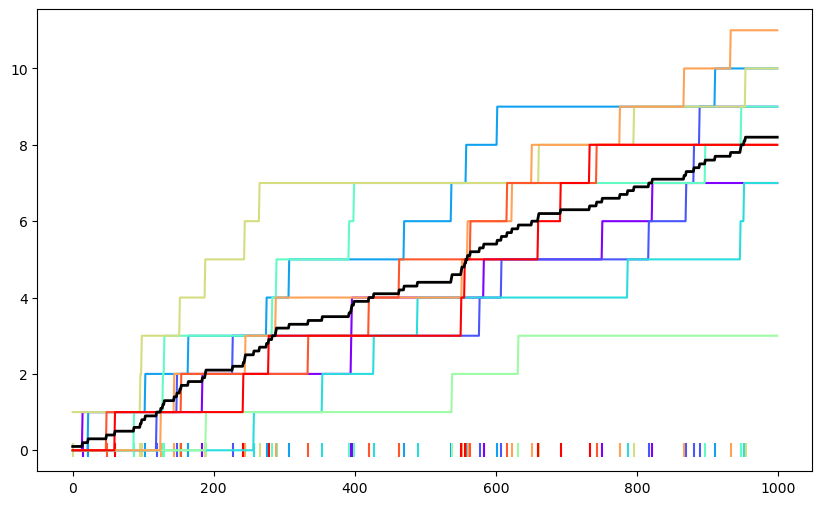

In [31]:
dotted_point_poisson_plot(counting_process_nd_result, num_samples, independent_processes)

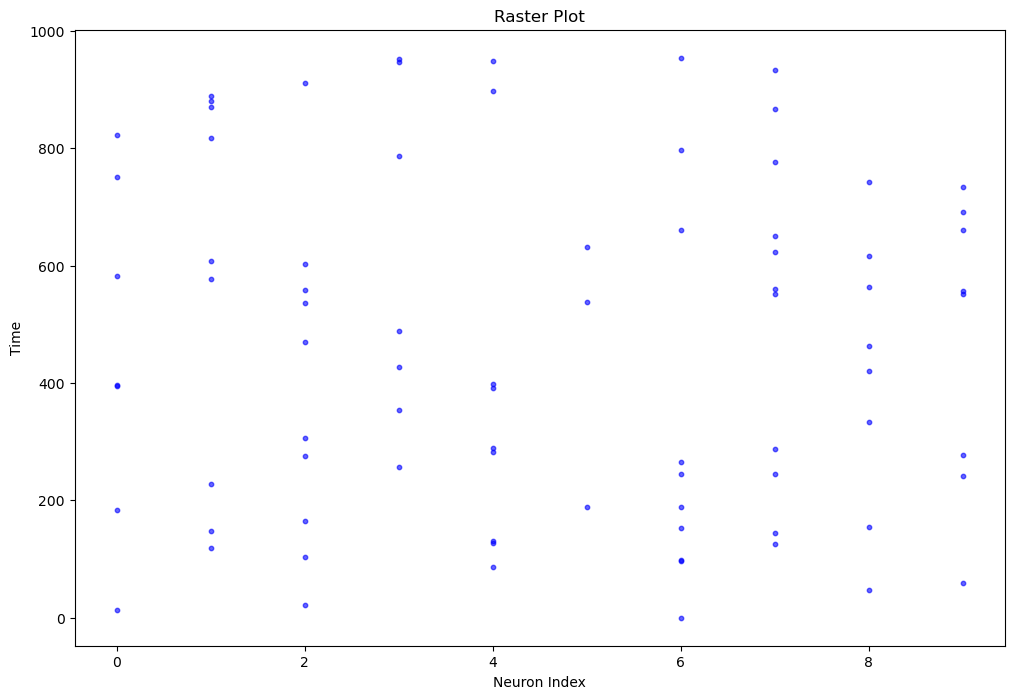

In [39]:
raster_plot(independent_processes, num_samples)

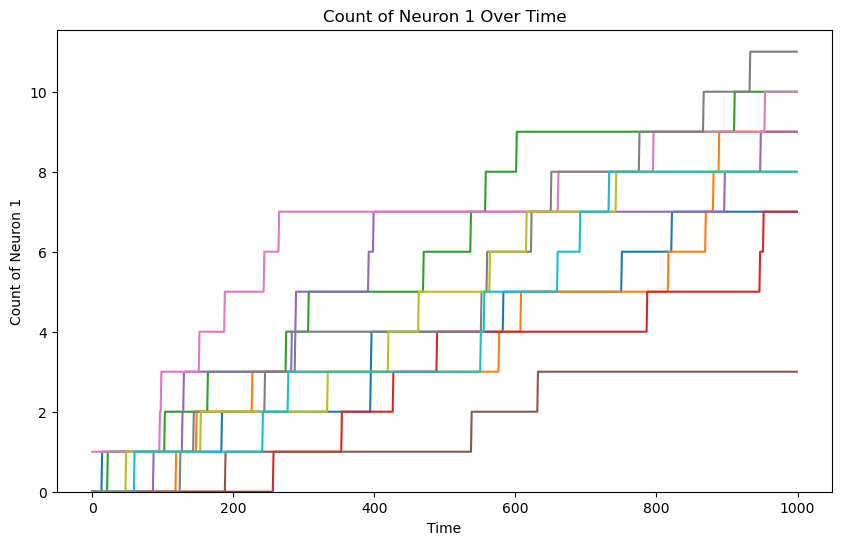

In [41]:
plot_count_neuron1_vs_time(counting_process_nd_result, num_samples)

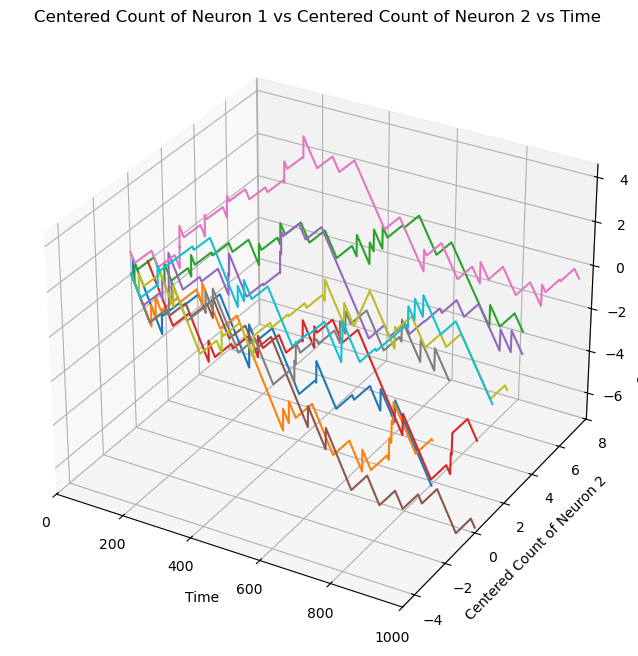

In [43]:
plot_centered_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_29920\1282071392.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (counting_process_nd_result[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_29920\1282071392.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (counting_process_nd_result[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_29920\1282071392.py:9: RuntimeWarning: divide by zero encountered in divide
  neuron2_data = (counting_process_nd_result[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_29920\1282071392.py:8: RuntimeWarning: divide by zero encountered in divide
  neuron1_data = (counting_process_nd_result[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]


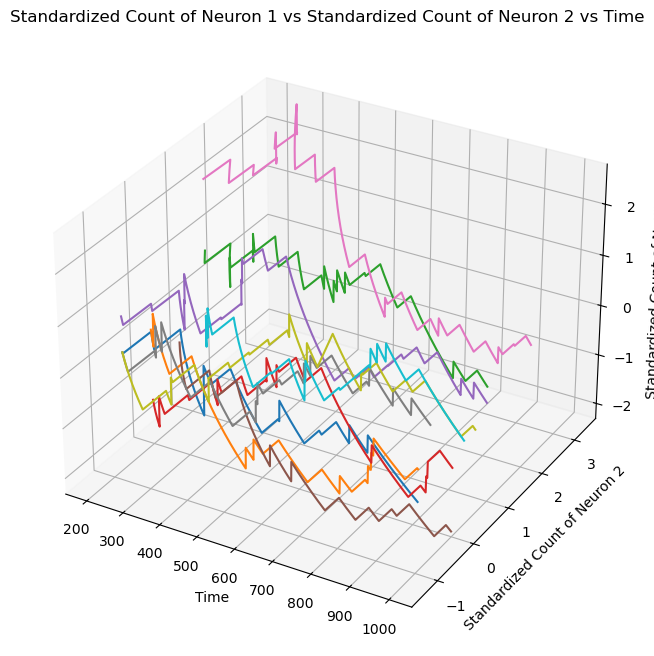

In [45]:
plot_standardized_staircase_3d(counting_process_nd_result, num_samples, theoretical_means, theoretical_std_dev, t0)

In [ ]:
#plot_centered_staircase_3d(counting_process_nd_result_LIF, num_samples, theoretical_means, theoretical_std_dev)

In [ ]:
#plot_standardized_staircase_3d(counting_process_nd_result_LIF, num_samples, theoretical_means, theoretical_std_dev, t0)